
--- Dataset Preview ---
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801

--- Missing Values ---
Gender    0
Height    0
Weight    0
dtype: int64


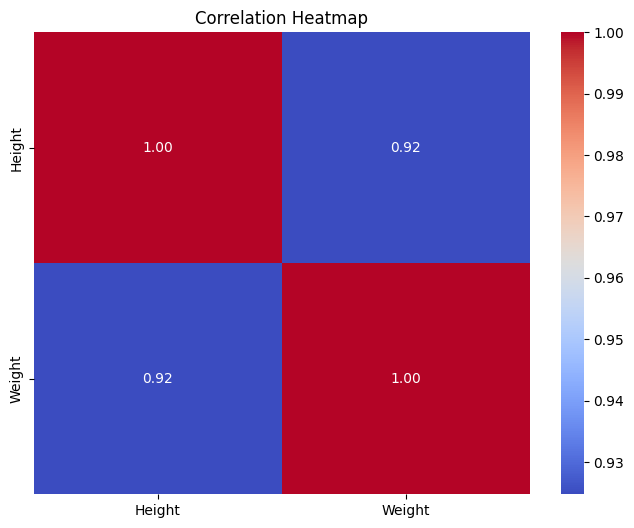


✅ Preprocessing Complete!

--- Linear Regression Evaluation ---
MSE: 104.73832247309385
RMSE: 10.23417424480812
MAE: 7.99861426581448
R²: 0.8999960770984344

--- Random Forest Evaluation ---
MSE: 145.1226678524896
RMSE: 12.04668700732652
MAE: 9.51551299925871
R²: 0.8614371918080121

--- Neural Network Evaluation ---
MSE: 105.01972939755241
RMSE: 10.247913416766966
MAE: 8.021856892790176
R²: 0.8997273903779196

--- Decision Tree Evaluation ---
MSE: 196.80526979329738
RMSE: 14.028730156122377
MAE: 11.12733043736598
R²: 0.8120907556822228

✅ All Models Trained and Evaluated Successfully!


In [ ]:
# === REGRESSION MODEL COMPARISON: LINEAR, RANDOM FOREST, NEURAL NETWORK, DECISION TREE ===

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# === 1. LOAD DATA ===
# You can replace this file name with any dataset (like "WineQT.csv" or "weight-height.csv")
df = pd.read_csv("weight-height.csv")

# === 2. DEFINE TARGET AND FEATURES ===
target = "Weight"     # change to 'quality' if using WineQT.csv
features = [col for col in df.columns if col != target]

# === 3. INITIAL DATA CHECK ===
print("\n--- Dataset Preview ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# === 4. VISUALIZE CORRELATION (Optional) ===
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# === 5. TRAIN-TEST SPLIT ===
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === 6. PREPROCESSING ===
# Handle missing values
for col in X_train.columns:
    if X_train[col].dtypes == 'object':
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

# Handle outliers using IQR
for col in X_train.select_dtypes(include=np.number).columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median_val = X_train[col].median()
    X_train[col] = np.where((X_train[col] < lower) | (X_train[col] > upper), median_val, X_train[col])
    X_test[col] = np.where((X_test[col] < lower) | (X_test[col] > upper), median_val, X_test[col])

# Encode categorical columns
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

# Align columns (to ensure same structure)
X_train_final, X_test_final = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print("\n✅ Preprocessing Complete!")

# === 7. SCALE FOR LINEAR + NN MODELS ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# === 8. DEFINE EVALUATION FUNCTION ===
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))

# === 9. TRAIN & EVALUATE MODELS ===

## 🔹 Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_pred = lin_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lin_pred)

## 🔹 Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
rf_pred = rf_model.predict(X_test_final)
evaluate_model("Random Forest", y_test, rf_pred)

## 🔹 Neural Network Regressor
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                        solver='adam', max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_pred = nn_model.predict(X_test_scaled)
evaluate_model("Neural Network", y_test, nn_pred)

## 🔹 Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_final, y_train)
dt_pred = dt_model.predict(X_test_final)
evaluate_model("Decision Tree", y_test, dt_pred)

print("\n✅ All Models Trained and Evaluated Successfully!")


In [ ]:
# === CLASSIFICATION MODEL COMPARISON: LOGISTIC, DECISION TREE, RANDOM FOREST, NEURAL NETWORK ===

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# === 1. LOAD DATA ===
df = pd.read_csv("data_science_job.csv")

# === 2. INITIAL ANALYSIS ===
print("--- Dataset Head ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())

target = "target"

# Drop rows where target is missing
df.dropna(subset=[target], inplace=True)

# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title("Class Distribution")
plt.show()

# === 3. TRAIN-TEST SPLIT ===
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 4. DATA PREPROCESSING (IMPUTATION) ===
for col in X_train.columns:
    if X_train[col].dtypes == "object":
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
print("✅ Missing value imputation complete!")

# === 5. ENCODING ===
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_train_final, X_test_final = X_train_encoded.align(
    X_test_encoded, axis=1, fill_value=0, join="left"
)
print("✅ Feature encoding complete!")

# === 6. SCALE FOR MODELS THAT NEED IT ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# === 7. DEFINE EVALUATION FUNCTION ===
def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))


# === 8. TRAIN + EVALUATE MODELS ===

## 🔹 Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, log_pred)

## 🔹 Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_final, y_train)
dt_pred = dt_model.predict(X_test_final)
evaluate_model("Decision Tree", y_test, dt_pred)

## 🔹 Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
rf_pred = rf_model.predict(X_test_final)
evaluate_model("Random Forest", y_test, rf_pred)

## 🔹 Neural Network
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32),
                         activation='relu',
                         solver='adam',
                         max_iter=1000,
                         random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_pred = nn_model.predict(X_test_scaled)
evaluate_model("Neural Network", y_test, nn_pred)

print("\n✅ All models trained and evaluated successfully!")